In [16]:
# load file from google drive (im on colab)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print('j')

In [18]:
import kagglehub
import shutil
import os

src_path = kagglehub.dataset_download("mengcius/cinic10")

Using Colab cache for faster access to the 'cinic10' dataset.


In [9]:
src_path + '/valid/'

'/kaggle/input/cinic10/valid/'

In [4]:
os.chdir('/content/drive/MyDrive/DL/')

In [ ]:
# !python /content/drive/MyDrive/DL/code/few_shot_phase_1.py

Found 6 datasets. Starting master training loop...
⏩ Skipping resnet50 on 10shot_50aug_standard_rotate: Already trained!
⏩ Skipping efficientnetb4 on 10shot_50aug_standard_rotate: Already trained!

--- Training Contrastive Network on: data/augmented_experiments/10shot_50aug_standard_rotate ---
/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
[xception] Unfrozen last 3 layers/blocks + projection head. Trainable params: 10,278,608
Epoch [1/20] | Loss: 2.9317
Epoch [2/20] | Loss: 1.8784
Epoch [3/20] | Loss: 1.2738
Epoch [4/20] | Loss: 1.0873
Epoch [5/20] | Loss: 1.0800
Epoch [6/20] | Loss: 1.0233
Epoch [7/20] | Loss: 1.0632
Epoch [8/20] | Loss: 1.0566
Epoch [9/20] | Loss: 1.0348
Epoch [10/20] | Loss: 1.0067
Epoch [11/20] | Loss: 0.9942
Epoch [12/20] | Loss: 0.9914
Epoch [13/20] | Loss: 1.0226
Epoch [14/20] | Loss: 0.9870
Epoch [15/20] | Loss: 1.0098
Epoch [16/20] | Loss

In [19]:
!python /content/drive/MyDrive/DL/code/contrastive_evaluation_1.py

Found 6 experimental datasets. Starting evaluation...

Evaluating Experiment: 10shot_50aug_standard_rotate

--- Evaluating resnet50 on cuda ---
Loaded weights from pretrained_encoders_contrastive/resnet50_10shot_50aug_standard_rotate.pth
Building balanced query subset...
Sub-sampled Validation Set: 9000 images total.
Computing class prototypes from the Support Set...
Extracting Support Features: 100% 2/2 [00:02<00:00,  1.01s/it]
Computed 10 prototypes of dimension 2048.
Evaluating Query Set against Prototypes...
Evaluating: 100% 141/141 [01:30<00:00,  1.55it/s]
Results -> Acc: 33.24% | F1: 32.88%

--- Evaluating efficientnetb4 on cuda ---
Loaded weights from pretrained_encoders_contrastive/efficientnetb4_10shot_50aug_standard_rotate.pth
Building balanced query subset...
Sub-sampled Validation Set: 9000 images total.
Computing class prototypes from the Support Set...
Extracting Support Features: 100% 2/2 [00:01<00:00,  1.08it/s]
Computed 10 prototypes of dimension 1792.
Evaluating Query

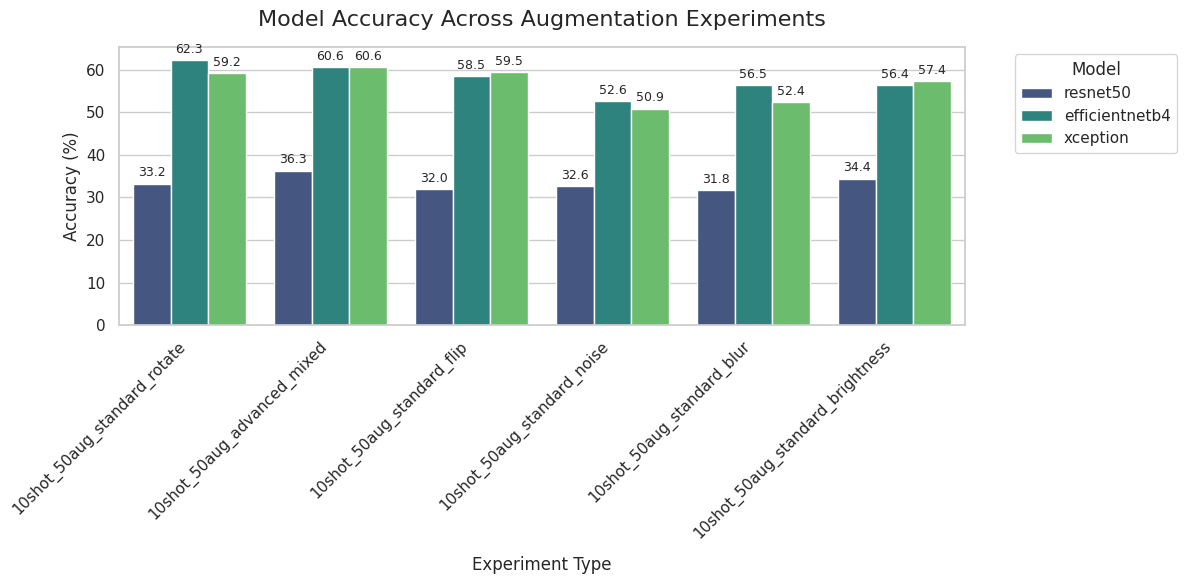

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the results
csv_path = "evaluation_results.csv"
try:
    df = pd.read_csv(csv_path)
except FileNotFoundError:
    print(f"Could not find {csv_path}. Make sure the evaluation script finished running!")
    exit()

# 2. Set up the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6)) # Make it wide to accommodate long experiment names

# 3. Create the grouped bar chart
# We are plotting Accuracy, but you can change y to 'F1_Score', 'Precision', or 'Recall'
ax = sns.barplot(
    data=df, 
    x="Experiment", 
    y="Accuracy", 
    hue="Model",
    palette="viridis" # A colorblind-friendly, professional color palette
)

# 4. Format the labels and title
plt.title("Model Accuracy Across Augmentation Experiments", fontsize=16, pad=15)
plt.xlabel("Experiment Type", fontsize=12, labelpad=10)
plt.ylabel("Accuracy (%)", fontsize=12)

# Rotate the x-axis labels by 45 degrees so they don't overlap
plt.xticks(rotation=45, ha='right')

# Move the legend outside the plot so it doesn't block any bars
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')

# 5. Add value labels on top of each bar (Optional but highly recommended)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, size=9)

# Adjust layout so nothing gets cut off when saving
plt.tight_layout()

# 6. Save the plot to a file and display it
plt.savefig("evaluation_accuracy_plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [26]:
import seaborn as sns
import pandas as pd
df1 = pd.read_csv('../evaluation_results_phase2_1.csv')
df2 = pd.read_csv('../evaluation_results_phase2_2.csv')
df3 = pd.read_csv('../evaluation_results_phase2.csv')

In [27]:
plotdata = pd.concat([df1, df2, df3])

In [28]:
plotdata

,Experiment,Model,L_Value,Accuracy,Precision,Recall,F1_Score
0,10shot_50aug_standard_rotate,efficientnetb4,5,53.23,60.61,53.23,53.24
1,10shot_50aug_standard_rotate,efficientnetb4,15,54.53,60.63,54.53,54.83
2,10shot_50aug_standard_rotate,efficientnetb4,30,54.67,61.89,54.67,54.90
3,10shot_50aug_standard_rotate,efficientnetb4,50,55.11,61.88,55.11,55.60
4,10shot_50aug_standard_mixed,efficientnetb4,5,55.49,61.31,55.49,55.49
5,10shot_50aug_standard_mixed,efficientnetb4,15,54.71,61.13,54.71,55.16
6,10shot_50aug_standard_mixed,efficientnetb4,30,55.06,61.04,55.06,55.07
7,10shot_50aug_standard_mixed,efficientnetb4,50,53.11,59.59,53.11,52.93
0,10shot_50aug_standard_rotate,efficientnetb4,0,55.30,61.03,55.30,55.65
1,10shot_50aug_standard_mixed,efficientnetb4,0,55.47,61.70,55.47,55.89


<Axes: xlabel='L_Value', ylabel='Accuracy'>

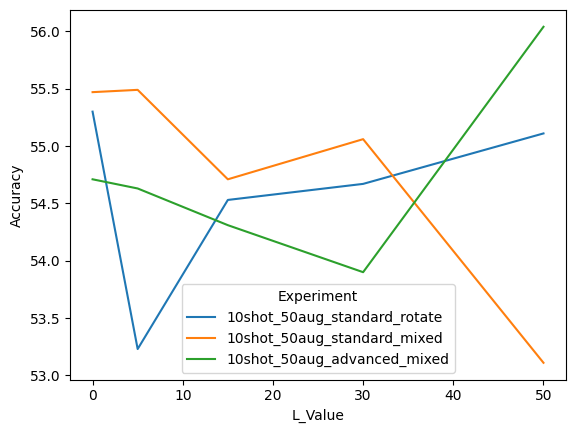

In [29]:
sns.lineplot(plotdata, x = 'L_Value', y = 'Accuracy', hue= 'Experiment')

In [14]:
import os
from pathlib import Path

def verify_subsets(target_dir: str):
    target_path = Path(target_dir)
    # Get all experiment folders
    experiments = [d for d in target_path.iterdir() if d.is_dir()]
    
    if not experiments:
        print("No experiments found in target directory.")
        return

    # Dictionary to store filenames: {experiment_name: {class_name: set(filenames)}}
    results = {}

    for exp in experiments:
        results[exp.name] = {}
        for cls_dir in exp.iterdir():
            if cls_dir.is_dir():
                # Extract only the original filenames (stripping the 'orig_' prefix)
                orig_files = {f.name.replace("orig_", "") for f in cls_dir.glob("orig_*")}
                results[exp.name][cls_dir.name] = orig_files

    # Compare all experiments against the first one
    first_exp_name = list(results.keys())[0]
    reference = results[first_exp_name]
    
    print(f"--- Verification Report (Reference: {first_exp_name}) ---")
    
    all_match = True
    for exp_name, classes in results.items():
        if exp_name == first_exp_name:
            continue
            
        for cls_name, files in classes.items():
            ref_files = reference.get(cls_name, set())
            if files != ref_files:
                print(f"❌ MISMATCH found in experiment: {exp_name}")
                print(f"   Class '{cls_name}' has different source images.")
                all_match = False
            
    if all_match:
        print("✅ Success: All experiments used the exact same subset of original photos.")

if __name__ == "__main__":
    TARGET_DATA_DIR = "../data/augmented_experiments"
    verify_subsets(TARGET_DATA_DIR)

--- Verification Report (Reference: 10shot_50aug_advanced_mixed) ---
❌ MISMATCH found in experiment: 10shot_50aug_standard_blur
   Class 'airplane' has different source images.
❌ MISMATCH found in experiment: 10shot_50aug_standard_blur
   Class 'automobile' has different source images.
❌ MISMATCH found in experiment: 10shot_50aug_standard_blur
   Class 'bird' has different source images.
❌ MISMATCH found in experiment: 10shot_50aug_standard_blur
   Class 'deer' has different source images.
❌ MISMATCH found in experiment: 10shot_50aug_standard_blur
   Class 'dog' has different source images.
❌ MISMATCH found in experiment: 10shot_50aug_standard_blur
   Class 'frog' has different source images.
❌ MISMATCH found in experiment: 10shot_50aug_standard_blur
   Class 'horse' has different source images.
❌ MISMATCH found in experiment: 10shot_50aug_standard_blur
   Class 'ship' has different source images.
❌ MISMATCH found in experiment: 10shot_50aug_standard_blur
   Class 'truck' has different